In [1]:
!pip install tensorflow matplotlib numpy seaborn scikit-learn

In [2]:
# ============================================================
# HANDWRITTEN CHARACTER RECOGNITION
# VertexMind Internship - Task 3
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.datasets import mnist

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

from tensorflow.keras.utils import to_categorical

from sklearn.metrics import confusion_matrix

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [3]:
# Load dataset

(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Dataset Loaded Successfully")

print("Training Shape:", X_train.shape)

print("Testing Shape:", X_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Dataset Loaded Successfully
Training Shape: (60000, 28, 28)
Testing Shape: (10000, 28, 28)


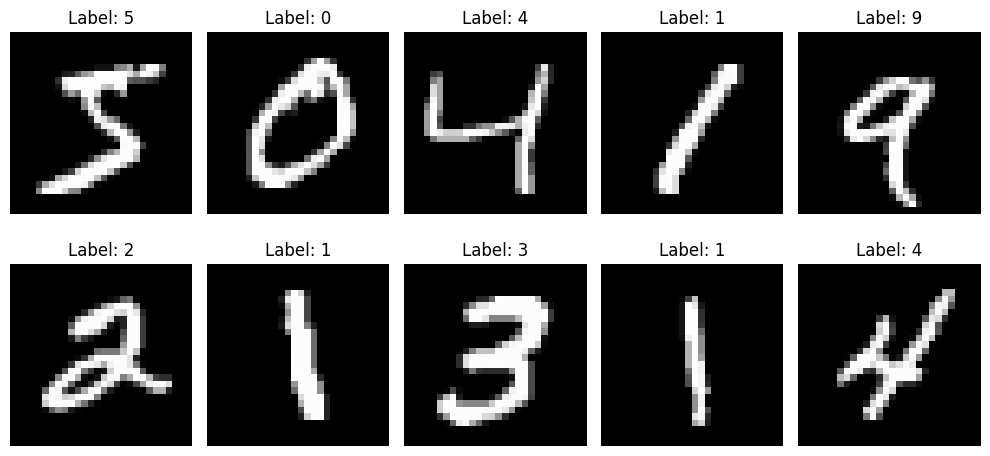

In [4]:
# Display sample handwritten digits

plt.figure(figsize=(10,5))

for i in range(10):

    plt.subplot(2,5,i+1)

    plt.imshow(X_train[i], cmap='gray')

    plt.title(f"Label: {y_train[i]}")

    plt.axis('off')

plt.tight_layout()

plt.show()

In [5]:
# Normalize pixel values

X_train = X_train / 255.0
X_test = X_test / 255.0

# Reshape for CNN

X_train = X_train.reshape(-1,28,28,1)
X_test = X_test.reshape(-1,28,28,1)

# One-hot encode labels

y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

print("Preprocessing Completed")

Preprocessing Completed


In [6]:
# Build CNN Model

model = Sequential()

# First CNN Layer

model.add(
    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(28,28,1)
    )
)

model.add(MaxPooling2D(pool_size=(2,2)))

# Second CNN Layer

model.add(
    Conv2D(
        64,
        (3,3),
        activation='relu'
    )
)

model.add(MaxPooling2D(pool_size=(2,2)))

# Flatten Layer

model.add(Flatten())

# Dense Layer

model.add(Dense(128, activation='relu'))

model.add(Dropout(0.3))

# Output Layer

model.add(Dense(10, activation='softmax'))

# Compile Model

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Display summary

model.summary()

c:\Users\hp\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# Train CNN model

history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 14s 16ms/step - accuracy: 0.9314 - loss: 0.2267 - val_accuracy: 0.9798 - val_loss: 0.0680
Epoch 2/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 16s 21ms/step - accuracy: 0.9777 - loss: 0.0736 - val_accuracy: 0.9866 - val_loss: 0.0443
Epoch 3/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.9844 - loss: 0.0512 - val_accuracy: 0.9881 - val_loss: 0.0382
Epoch 4/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.9879 - loss: 0.0400 - val_accuracy: 0.9896 - val_loss: 0.0351
Epoch 5/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.9897 - loss: 0.0331 - val_accuracy: 0.9892 - val_loss: 0.0349


In [8]:
# Evaluate model

loss, accuracy = model.evaluate(X_test, y_test)

print(f"Test Accuracy: {accuracy:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9911 - loss: 0.0274
Test Accuracy: 0.9911


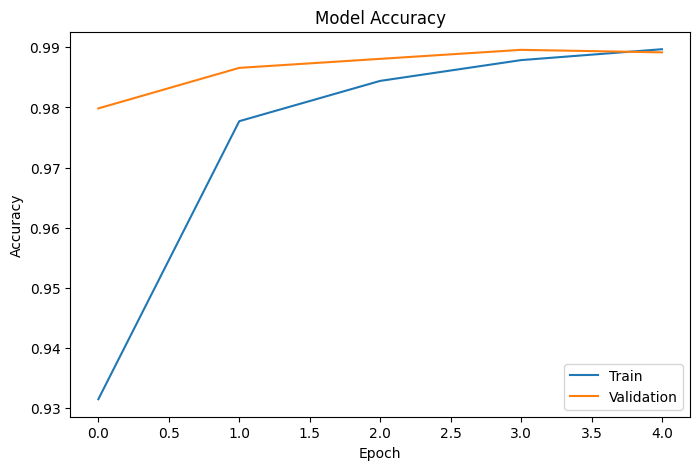

In [9]:
# Plot training accuracy

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'])

plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')

plt.xlabel('Epoch')

plt.ylabel('Accuracy')

plt.legend(['Train', 'Validation'])

plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


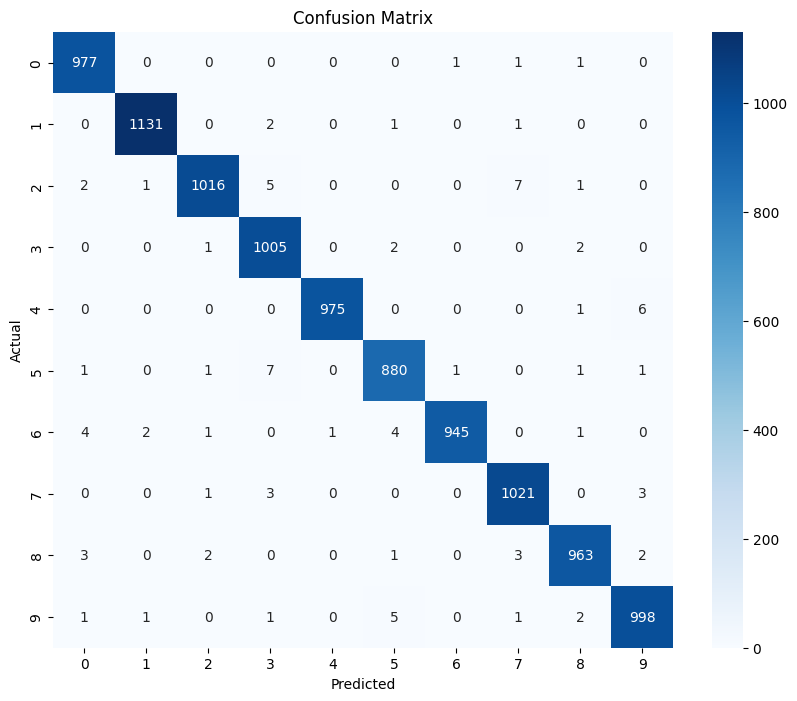

In [10]:
# Predict values

y_pred = model.predict(X_test)

# Convert predictions

y_pred_classes = np.argmax(y_pred, axis=1)

y_true = np.argmax(y_test, axis=1)

# Confusion matrix

cm = confusion_matrix(y_true, y_pred_classes)

# Plot

plt.figure(figsize=(10,8))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


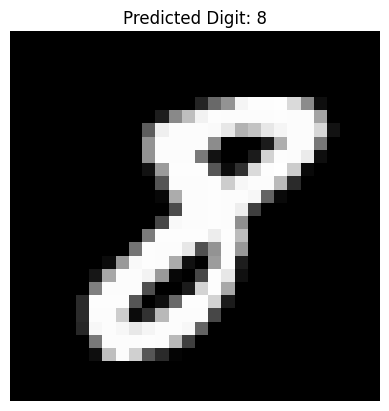

In [11]:
# ============================================================
# PREDICT HANDWRITTEN DIGIT
# ============================================================

# Select random image

index = np.random.randint(0, len(X_test))

sample_image = X_test[index]

# Predict

prediction = model.predict(
    sample_image.reshape(1,28,28,1)
)

predicted_digit = np.argmax(prediction)

# Display image

plt.imshow(sample_image.reshape(28,28), cmap='gray')

plt.title(f"Predicted Digit: {predicted_digit}")

plt.axis('off')

plt.show()